# Оценка глубины по одному изображению

## Введение

Оценка глубины — ключевая задача для извлечения геометрии сцены из 2D-изображений.
Цель _оценки глубины по одному изображению_ — предсказать значение глубины для каждого пикселя,
используя только одно RGB-изображение в качестве входных данных.
В этом примере показан подход построения модели оценки глубины с использованием сверточной нейронной сети
и простых функций потерь.

![depth](https://paperswithcode.com/media/thumbnails/task/task-0000000605-d9849a91.jpg)

## Настройка

In [3]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import sys

import tensorflow as tf
import keras
from keras import layers
from keras import ops
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

keras.utils.set_random_seed(123)

## Загрузка датасета

Для этого примера используется датасет **DIODE: A Dense Indoor and Outdoor Depth Dataset**.
Однако для модели используется валидационная выборка, из которой генерируются обучающие и оценочные подмножества.
Причина использования валидационной выборки заключается в том, что обучающая выборка составляет 81 ГБ данных,
что затрудняет её загрузку по сравнению с валидационной выборкой объёмом всего 2,6 ГБ.
Другие датасеты, которые можно использовать, включают **[NYU-v2](https://cs.nyu.edu/~silberman/datasets/nyu_depth_v2.html)**
и **[KITTI](http://www.cvlibs.net/datasets/kitti/)**.

In [4]:
annotation_folder = "/dataset/"
if not os.path.exists(os.path.abspath(".") + annotation_folder):
    annotation_zip = keras.utils.get_file(
        "val.tar.gz",
        cache_subdir=os.path.abspath("."),
        origin="http://diode-dataset.s3.amazonaws.com/val.tar.gz",
        extract=True,
    )

2774625282/2774625282 ━━━━━━━━━━━━━━━━━━━━ 71s 0us/step


## Подготовка датасета

Для обучения модели оценки глубины используются только внутренние изображения.

In [5]:
path = "/content/val_extracted/val/indoors"

filelist = []

for root, dirs, files in os.walk(path):
    for file in files:
        filelist.append(os.path.join(root, file))

filelist.sort()
data = {
    "image": [x for x in filelist if x.endswith(".png")],
    "depth": [x for x in filelist if x.endswith("_depth.npy")],
    "mask": [x for x in filelist if x.endswith("_depth_mask.npy")],
}
df = pd.DataFrame(data)

df = df.sample(frac=1, random_state=42)

## Подготовка гиперпараметров

In [6]:
HEIGHT = 256
WIDTH = 256
LR = 0.00001
EPOCHS = 40
BATCH_SIZE = 32

## Построение пайплайна данных

1. Пайплайн принимает DataFrame, содержащий пути к RGB-изображениям,
а также файлы глубины и маски глубины.
2. Он считывает и изменяет размер RGB-изображений.
3. Считывает файлы глубины и маски глубины, обрабатывает их для генерации карты глубины и
изменяет её размер.
4. Возвращает RGB-изображения и карты глубины для пакета.

In [7]:

class DataGenerator(keras.utils.PyDataset):
    def __init__(self, data, batch_size=6, dim=(768, 1024), n_channels=3, shuffle=True):
        super().__init__()
        """
        Initialization
        """
        self.data = data
        self.indices = self.data.index.tolist()
        self.dim = dim
        self.n_channels = n_channels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.min_depth = 0.1
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        if (index + 1) * self.batch_size > len(self.indices):
            self.batch_size = len(self.indices) - index * self.batch_size
        # Generate one batch of data
        # Generate indices of the batch
        index = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        # Find list of IDs
        batch = [self.indices[k] for k in index]
        x, y = self.data_generation(batch)

        return x, y

    def on_epoch_end(self):
        """
        Updates indexes after each epoch
        """
        self.index = np.arange(len(self.indices))
        if self.shuffle == True:
            np.random.shuffle(self.index)

    def load(self, image_path, depth_map, mask):
        """Load input and target image."""

        image_ = cv2.imread(image_path)
        image_ = cv2.cvtColor(image_, cv2.COLOR_BGR2RGB)
        image_ = cv2.resize(image_, self.dim)
        image_ = tf.image.convert_image_dtype(image_, tf.float32)

        depth_map = np.load(depth_map).squeeze()

        mask = np.load(mask)
        mask = mask > 0

        max_depth = min(300, np.percentile(depth_map, 99))
        depth_map = np.clip(depth_map, self.min_depth, max_depth)
        depth_map = np.log(depth_map, where=mask)

        depth_map = np.ma.masked_where(~mask, depth_map)

        depth_map = np.clip(depth_map, 0.1, np.log(max_depth))
        depth_map = cv2.resize(depth_map, self.dim)
        depth_map = np.expand_dims(depth_map, axis=2)
        depth_map = tf.image.convert_image_dtype(depth_map, tf.float32)

        return image_, depth_map

    def data_generation(self, batch):
        x = np.empty((self.batch_size, *self.dim, self.n_channels))
        y = np.empty((self.batch_size, *self.dim, 1))

        for i, batch_id in enumerate(batch):
            x[i,], y[i,] = self.load(
                self.data["image"][batch_id],
                self.data["depth"][batch_id],
                self.data["mask"][batch_id],
            )
        x, y = x.astype("float32"), y.astype("float32")
        return x, y


## Визуализация примеров


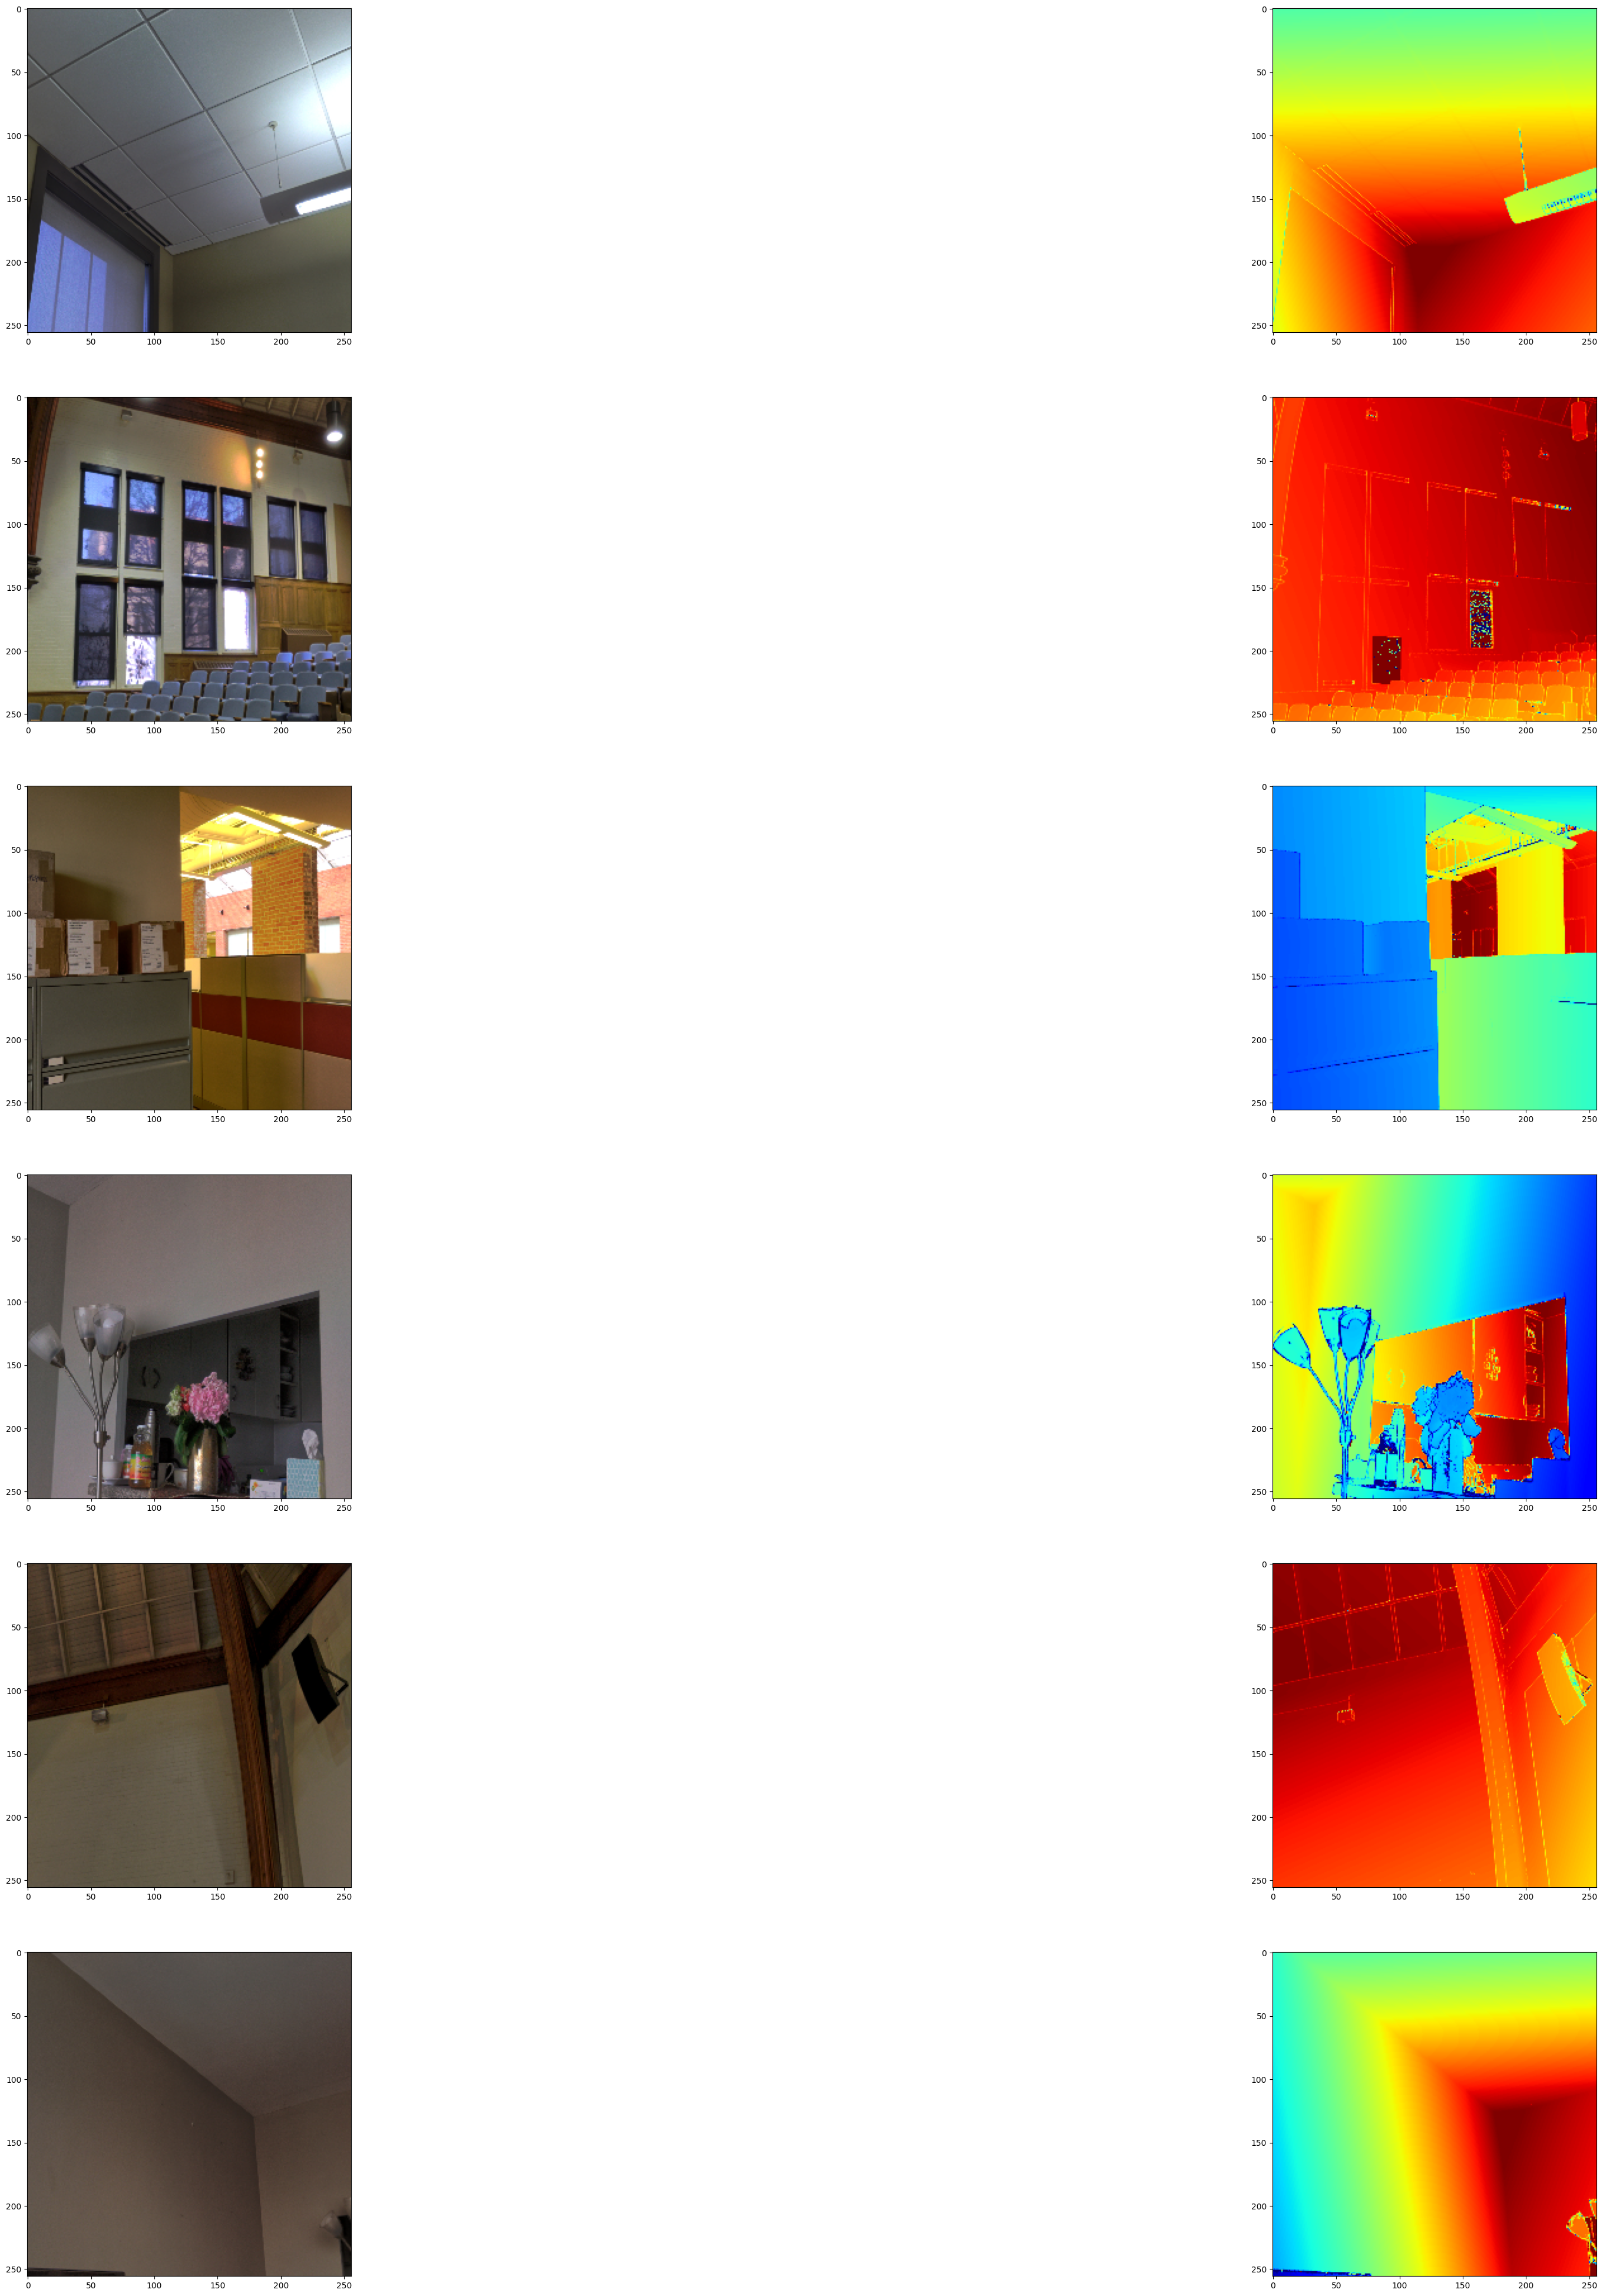

In [8]:

def visualize_depth_map(samples, test=False, model=None):
    input, target = samples
    cmap = plt.cm.jet
    cmap.set_bad(color="black")

    if test:
        pred = model.predict(input)
        fig, ax = plt.subplots(6, 3, figsize=(50, 50))
        for i in range(6):
            ax[i, 0].imshow((input[i].squeeze()))
            ax[i, 1].imshow((target[i].squeeze()), cmap=cmap)
            ax[i, 2].imshow((pred[i].squeeze()), cmap=cmap)

    else:
        fig, ax = plt.subplots(6, 2, figsize=(50, 50))
        for i in range(6):
            ax[i, 0].imshow((input[i].squeeze()))
            ax[i, 1].imshow((target[i].squeeze()), cmap=cmap)


visualize_samples = next(
    iter(DataGenerator(data=df, batch_size=6, dim=(HEIGHT, WIDTH)))
)
visualize_depth_map(visualize_samples)

## Визуализация из точек в 3D


In [9]:
depth_vis = np.flipud(visualize_samples[1][1].squeeze())  # target
img_vis = np.flipud(visualize_samples[0][1].squeeze())  # input

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection="3d")

STEP = 3
for x in range(0, img_vis.shape[0], STEP):
    for y in range(0, img_vis.shape[1], STEP):
        ax.scatter(
            [depth_vis[x, y]] * 3,
            [y] * 3,
            [x] * 3,
            c=tuple(img_vis[x, y, :3] / 255),
            s=3,
        )
    ax.view_init(45, 135)

Error in callback <function flush_figures at 0x7f0f3a4e4b80> (for post_execute):


KeyboardInterrupt: 

## Построение модели

1. Базовая модель основана на U-Net.
2. Добавлены пропускные соединения в блоке понижения разрешения.

In [10]:

class DownscaleBlock(layers.Layer):
    def __init__(
        self, filters, kernel_size=(3, 3), padding="same", strides=1, **kwargs
    ):
        super().__init__(**kwargs)
        self.convA = layers.Conv2D(filters, kernel_size, strides, padding)
        self.convB = layers.Conv2D(filters, kernel_size, strides, padding)
        self.reluA = layers.LeakyReLU(negative_slope=0.2)
        self.reluB = layers.LeakyReLU(negative_slope=0.2)
        self.bn2a = layers.BatchNormalization()
        self.bn2b = layers.BatchNormalization()

        self.pool = layers.MaxPool2D((2, 2), (2, 2))

    def call(self, input_tensor):
        d = self.convA(input_tensor)
        x = self.bn2a(d)
        x = self.reluA(x)

        x = self.convB(x)
        x = self.bn2b(x)
        x = self.reluB(x)

        x += d
        p = self.pool(x)
        return x, p


class UpscaleBlock(layers.Layer):
    def __init__(
        self, filters, kernel_size=(3, 3), padding="same", strides=1, **kwargs
    ):
        super().__init__(**kwargs)
        self.us = layers.UpSampling2D((2, 2))
        self.convA = layers.Conv2D(filters, kernel_size, strides, padding)
        self.convB = layers.Conv2D(filters, kernel_size, strides, padding)
        self.reluA = layers.LeakyReLU(negative_slope=0.2)
        self.reluB = layers.LeakyReLU(negative_slope=0.2)
        self.bn2a = layers.BatchNormalization()
        self.bn2b = layers.BatchNormalization()
        self.conc = layers.Concatenate()

    def call(self, x, skip):
        x = self.us(x)
        concat = self.conc([x, skip])
        x = self.convA(concat)
        x = self.bn2a(x)
        x = self.reluA(x)

        x = self.convB(x)
        x = self.bn2b(x)
        x = self.reluB(x)

        return x


class BottleNeckBlock(layers.Layer):
    def __init__(
        self, filters, kernel_size=(3, 3), padding="same", strides=1, **kwargs
    ):
        super().__init__(**kwargs)
        self.convA = layers.Conv2D(filters, kernel_size, strides, padding)
        self.convB = layers.Conv2D(filters, kernel_size, strides, padding)
        self.reluA = layers.LeakyReLU(negative_slope=0.2)
        self.reluB = layers.LeakyReLU(negative_slope=0.2)

    def call(self, x):
        x = self.convA(x)
        x = self.reluA(x)
        x = self.convB(x)
        x = self.reluB(x)
        return x


## Определение потерь

Мы оптимизируем 3 потери в нашем режиме.
1. Индекс структурного сходства (SSIM).
2. L1-потери, или точечная глубина в нашем случае.
3. Потеря плавности хода по глубине.

Из трех функций потери скорости SSIM вносит наибольший вклад в повышение производительности модели.

In [11]:

def image_gradients(image):
    if len(ops.shape(image)) != 4:
        raise ValueError(
            "image_gradients expects a 4D tensor "
            "[batch_size, h, w, d], not {}.".format(ops.shape(image))
        )

    image_shape = ops.shape(image)
    batch_size, height, width, depth = ops.unstack(image_shape)

    dy = image[:, 1:, :, :] - image[:, :-1, :, :]
    dx = image[:, :, 1:, :] - image[:, :, :-1, :]

    # Return tensors with same size as original image by concatenating
    # zeros. Place the gradient [I(x+1,y) - I(x,y)] on the base pixel (x, y).
    shape = ops.stack([batch_size, 1, width, depth])
    dy = ops.concatenate([dy, ops.zeros(shape, dtype=image.dtype)], axis=1)
    dy = ops.reshape(dy, image_shape)

    shape = ops.stack([batch_size, height, 1, depth])
    dx = ops.concatenate([dx, ops.zeros(shape, dtype=image.dtype)], axis=2)
    dx = ops.reshape(dx, image_shape)

    return dy, dx


class DepthEstimationModel(keras.Model):
    def __init__(self):
        super().__init__()
        self.ssim_loss_weight = 0.85
        self.l1_loss_weight = 0.1
        self.edge_loss_weight = 0.9
        self.loss_metric = keras.metrics.Mean(name="loss")
        f = [16, 32, 64, 128, 256]
        self.downscale_blocks = [
            DownscaleBlock(f[0]),
            DownscaleBlock(f[1]),
            DownscaleBlock(f[2]),
            DownscaleBlock(f[3]),
        ]
        self.bottle_neck_block = BottleNeckBlock(f[4])
        self.upscale_blocks = [
            UpscaleBlock(f[3]),
            UpscaleBlock(f[2]),
            UpscaleBlock(f[1]),
            UpscaleBlock(f[0]),
        ]
        self.conv_layer = layers.Conv2D(1, (1, 1), padding="same", activation="tanh")

    def calculate_loss(self, target, pred):
        # Edges
        dy_true, dx_true = image_gradients(target)
        dy_pred, dx_pred = image_gradients(pred)
        weights_x = ops.cast(ops.exp(ops.mean(ops.abs(dx_true))), "float32")
        weights_y = ops.cast(ops.exp(ops.mean(ops.abs(dy_true))), "float32")

        # Depth smoothness
        smoothness_x = dx_pred * weights_x
        smoothness_y = dy_pred * weights_y

        depth_smoothness_loss = ops.mean(abs(smoothness_x)) + ops.mean(
            abs(smoothness_y)
        )

        # Structural similarity (SSIM) index
        ssim_loss = ops.mean(
            1
            - tf.image.ssim(
                target, pred, max_val=WIDTH, filter_size=7, k1=0.01**2, k2=0.03**2
            )
        )
        # Point-wise depth
        l1_loss = ops.mean(ops.abs(target - pred))

        loss = (
            (self.ssim_loss_weight * ssim_loss)
            + (self.l1_loss_weight * l1_loss)
            + (self.edge_loss_weight * depth_smoothness_loss)
        )

        return loss

    @property
    def metrics(self):
        return [self.loss_metric]


    def train_step(self, batch_data):
        input, target = batch_data
        with tf.GradientTape() as tape:
            pred = self(input, training=True)
            loss = self.calculate_loss(target, pred)

        # Проверка на NaN в потере
        tf.debugging.check_numerics(loss, message="Loss contains NaN or Inf.")

        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))
        self.loss_metric.update_state(loss)
        return {"loss": self.loss_metric.result()}



    def test_step(self, batch_data):
        input, target = batch_data

        pred = self(input, training=False)
        loss = self.calculate_loss(target, pred)

        self.loss_metric.update_state(loss)
        return {
            "loss": self.loss_metric.result(),
        }

    def call(self, x):
        c1, p1 = self.downscale_blocks[0](x)
        c2, p2 = self.downscale_blocks[1](p1)
        c3, p3 = self.downscale_blocks[2](p2)
        c4, p4 = self.downscale_blocks[3](p3)

        bn = self.bottle_neck_block(p4)

        u1 = self.upscale_blocks[0](bn, c4)
        u2 = self.upscale_blocks[1](u1, c3)
        u3 = self.upscale_blocks[2](u2, c2)
        u4 = self.upscale_blocks[3](u3, c1)

        return self.conv_layer(u4)


## Model training

In [ ]:
optimizer = keras.optimizers.SGD(
    learning_rate=LR,
    nesterov=False,
)
model = DepthEstimationModel()
# Compile the model
model.compile(optimizer)

train_loader = DataGenerator(
    data=df[:260].reset_index(drop="true"), batch_size=BATCH_SIZE, dim=(HEIGHT, WIDTH)
)
validation_loader = DataGenerator(
    data=df[260:].reset_index(drop="true"), batch_size=BATCH_SIZE, dim=(HEIGHT, WIDTH)
)
model.fit(
    train_loader,
    epochs=EPOCHS,
    validation_data=validation_loader,
)

Epoch 1/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 247s 25s/step - loss: 0.7827 - val_loss: 0.7739
Epoch 2/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 66s 8s/step - loss: 0.8038 - val_loss: 0.7777
Epoch 3/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 64s 7s/step - loss: 0.7785 - val_loss: 0.7681
Epoch 4/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 81s 10s/step - loss: 0.6983 - val_loss: 0.7584
Epoch 5/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 65s 7s/step - loss: 0.6527 - val_loss: 0.7489
Epoch 6/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 99s 10s/step - loss: 0.7324 - val_loss: 0.7397
Epoch 7/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 65s 7s/step - loss: 0.7398 - val_loss: 0.7327
Epoch 8/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 81s 7s/step - loss: 0.6969 - val_loss: 0.7249
Epoch 9/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 83s 7s/step - loss: 0.6870 - val_loss: 0.7168
Epoch 10/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 85s 8s/step - loss: 0.7044 - val_loss: 0.7097
Epoch 11/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 96s 10s/step - loss: 0.6666 - val_loss: 0.7028
Epoch 12/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 81s 9s/step - loss: 0.7266 - val_loss: 0.6963
Epoch 13

In [ ]:
def save_model(model, model_name="depth_estimation_model_ver_3"):
    model.save(f"{model_name}.h5")
    print(f"Модель сохранена как {model_name}.h5")

save_model(model)

## Visualizing model output

We visualize the model output over the validation set.
The first image is the RGB image, the second image is the ground truth depth map image
and the third one is the predicted depth map image.

In [ ]:
test_loader = next(
    iter(
        DataGenerator(
            data=df[265:].reset_index(drop="true"), batch_size=6, dim=(HEIGHT, WIDTH)
        )
    )
)
visualize_depth_map(test_loader, test=True, model=model)

test_loader = next(
    iter(
        DataGenerator(
            data=df[300:].reset_index(drop="true"), batch_size=6, dim=(HEIGHT, WIDTH)
        )
    )
)
visualize_depth_map(test_loader, test=True, model=model)

## Possible improvements

1. You can improve this model by replacing the encoding part of the U-Net with a
pretrained DenseNet or ResNet.
2. Loss functions play an important role in solving this problem.
Tuning the loss functions may yield significant improvement.

## References

The following papers go deeper into possible approaches for depth estimation.
1. [Depth Prediction Without the Sensors: Leveraging Structure for Unsupervised Learning from Monocular Videos](https://arxiv.org/abs/1811.06152v1)
2. [Digging Into Self-Supervised Monocular Depth Estimation](https://openaccess.thecvf.com/content_ICCV_2019/papers/Godard_Digging_Into_Self-Supervised_Monocular_Depth_Estimation_ICCV_2019_paper.pdf)
3. [Deeper Depth Prediction with Fully Convolutional Residual Networks](https://arxiv.org/abs/1606.00373v2)

You can also find helpful implementations in the papers with code depth estimation task.

You can use the trained model hosted on [Hugging Face Hub](https://huggingface.co/spaces/keras-io/Monocular-Depth-Estimation)
and try the demo on [Hugging Face Spaces](https://huggingface.co/keras-io/monocular-depth-estimation).